In [1]:
import os 
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [2]:
t2p_save_path = "Z:/giocomo/esay/hipposs/social_interaction_data/2PData/alignROIs/social-0058-3"
plane = "plane0"

In [3]:
t2p_match_mat = np.load(os.path.join(t2p_save_path, 'track2p', f'{plane}_match_mat.npy'), allow_pickle=True)

track_ops_dict = np.load(os.path.join(t2p_save_path, 'track2p', 'track_ops.npy'), allow_pickle=True).item()
track_ops = SimpleNamespace(**track_ops_dict)

In [5]:
t2p_match_mat_allday = t2p_match_mat[~np.any(t2p_match_mat==None, axis=1),:]
t2p_match_mat_allday.shape

# t2p_5day_match = t2p_match_mat[(np.sum(t2p_match_mat == None, axis=1) ==1), :]
# t2p_5day_match.shape

(73, 6)

In [13]:
perc_cell_tracked = t2p_match_mat_allday.shape[0]/t2p_match_mat.shape[0]
print(perc_cell_tracked*100, "% cells tracked across all days")

11.550632911392405 % cells tracked across all days


In [14]:
def count_days(data):

    mask = np.array([[x is not None for x in row] for row in data])
    return mask.sum(axis=1)

def plot_presence_distribution(data, title="Cells tracked across days"):
    counts = count_days(data)
    plt.figure(figsize=(6,4))
    plt.hist(counts, bins=np.arange(counts.max()+2)-0.5, edgecolor='black')
    plt.xlabel("Days")
    plt.ylabel("Cells")
    plt.title(title)
    plt.xticks(range(counts.max()+1))
    plt.tight_layout()
    plt.show()


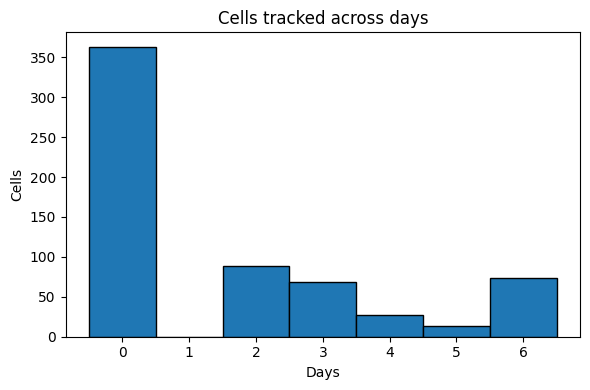

In [15]:
plot_presence_distribution(t2p_match_mat)

In [14]:
print('Datasets used for t2p:\n')
for ds_path in track_ops.all_ds_path:
    print(ds_path)

last_ds_path = track_ops.all_ds_path[-1]
print(f'We will look at the dataset saved at: {last_ds_path}')

# load the three files
last_ops = np.load(os.path.join(last_ds_path, 'suite2p', plane, 'ops.npy'), allow_pickle=True).item()
last_f = np.load(os.path.join(last_ds_path, 'suite2p', plane, 'F.npy'), allow_pickle=True)
iscell = np.load(os.path.join(last_ds_path, 'suite2p', plane, 'iscell.npy'), allow_pickle=True)

Datasets used for t2p:

Z:/giocomo/esay/hipposs/social_interaction_data/2PData/social-0051-1/29_06_2025
Z:/giocomo/esay/hipposs/social_interaction_data/2PData/social-0051-1/30_06_2025
Z:/giocomo/esay/hipposs/social_interaction_data/2PData/social-0051-1/01_07_2025
Z:/giocomo/esay/hipposs/social_interaction_data/2PData/social-0051-1/02_07_2025
Z:/giocomo/esay/hipposs/social_interaction_data/2PData/social-0051-1/03_07_2025
Z:/giocomo/esay/hipposs/social_interaction_data/2PData/social-0051-1/04_07_2025
We will look at the dataset saved at: Z:/giocomo/esay/hipposs/social_interaction_data/2PData/social-0051-1/04_07_2025


In [15]:
# we filter the traces based on suite2p's iscell probability (note: it is crucial to use the same probability as in the track2p settings to keep the correct indexing of matches)
iscell_thr = track_ops.iscell_thr

print(f'The iscell threshold used when running track2p was: {iscell_thr}')

if track_ops.iscell_thr==None:
    last_f_iscell = last_f[iscell[:, 0] == 1, :]

else:
    last_f_iscell = last_f[iscell[:, 1] > iscell_thr, :]

The iscell threshold used when running track2p was: 0.5


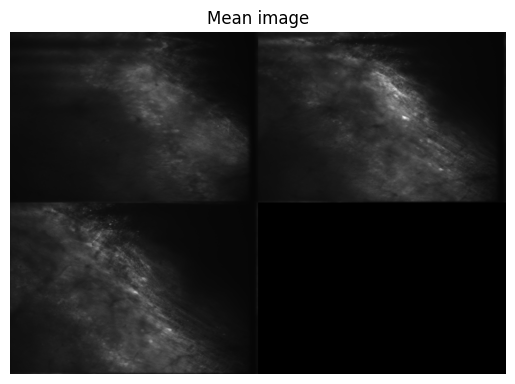

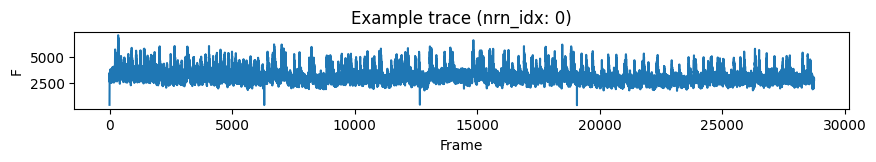

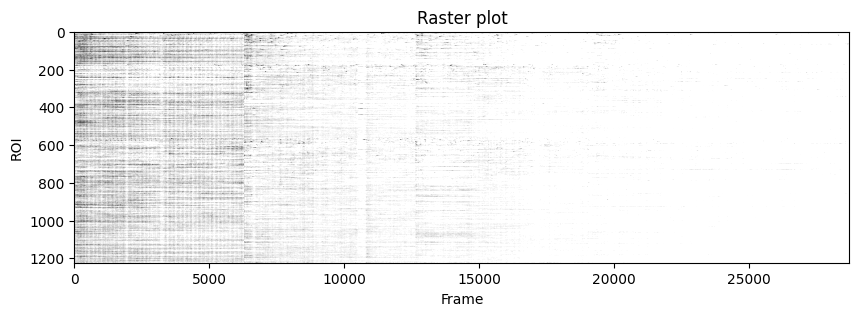

In [16]:
# now first plot the mean image of the movie (it is saved in ops.npy, for more info see the suite2p outputs documentation)
plt.imshow(last_ops['meanImg'], cmap='gray')
plt.axis('off')
plt.title('Mean image')
plt.show()

plt.figure(figsize=(10, 1))
nonmatch_nrn_idx = 0
plt.plot(last_f[nonmatch_nrn_idx, :])
plt.xlabel('Frame')
plt.ylabel('F')
plt.title(f'Example trace (nrn_idx: {nonmatch_nrn_idx})')
plt.show()

plt.figure(figsize=(10, 3))
plt.imshow(zscore(last_f_iscell, axis=1), aspect='auto', cmap='Greys', vmin=0, vmax=1.96)
plt.xlabel('Frame')
plt.ylabel('ROI')
plt.title('Raster plot')
plt.show()

In [9]:
iscell_thr = track_ops.iscell_thr # use the same threshold as when running the algo (to be consistent with indexing)

all_stat_t2p = []
all_f_t2p = []
all_ops = [] # ops dont change

for (i, ds_path) in enumerate(track_ops.all_ds_path):
    ops = np.load(os.path.join(ds_path, 'suite2p', plane, 'ops.npy'), allow_pickle=True).item()
    stat = np.load(os.path.join(ds_path, 'suite2p', plane, 'stat.npy'), allow_pickle=True)
    f = np.load(os.path.join(ds_path, 'suite2p', plane, 'F.npy'), allow_pickle=True)
    iscell = np.load(os.path.join(ds_path, 'suite2p', plane, 'iscell.npy'), allow_pickle=True)
    
    
    if track_ops.iscell_thr==None:
        stat_iscell = stat[iscell[:, 0] == 1]
        f_iscell = f[iscell[:, 0] == 1, :]

    else:
        stat_iscell = stat[iscell[:, 1] > iscell_thr]
        f_iscell = f[iscell[:, 1] > iscell_thr, :]
    
    
    # stat_t2p = stat_iscell[t2p_match_mat_allday[:,i].astype(int)]
    # f_t2p = f_iscell[t2p_match_mat_allday[:,i].astype(int), :]

    idx = t2p_5day_match[:,i]
    valid_mask = idx != None
    valid_idx = idx[valid_mask].astype(int)
    stat_t2p = stat_iscell[valid_idx]
    f_t2p=f_iscell[valid_idx,:]

    all_stat_t2p.append(stat_t2p)
    all_f_t2p.append(f_t2p)
    all_ops.append(ops)

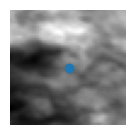

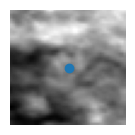

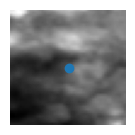

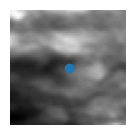

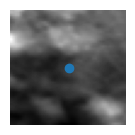

IndexError: index 0 is out of bounds for axis 0 with size 0

In [12]:
wind = 24
nrn_idx = 0

for i in range(len(track_ops.all_ds_path)):
    mean_img = all_ops[i]['meanImg']
    stat_t2p = all_stat_t2p[i]
    
    median_coord = stat_t2p[nrn_idx]['med']

    plt.figure(figsize=(1.5,1.5))
    plt.imshow(mean_img[int(median_coord[0])-wind:int(median_coord[0])+wind, int(median_coord[1])-wind:int(median_coord[1])+wind], cmap='gray') # plot a short window around the ROI centroid
    plt.scatter(wind, wind)
    plt.axis('off')
    plt.show()

In [41]:
len(all_stat_t2p[0])

19

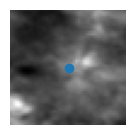

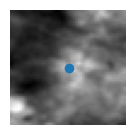

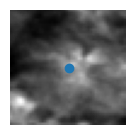

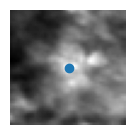

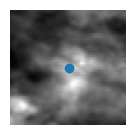

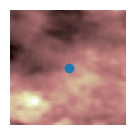

In [37]:
wind = 24
nrn_idx = 10

for i in range(len(track_ops.all_ds_path)):
    mean_img = all_ops[i]['meanImg']
    stat_t2p = all_stat_t2p[i]

    plt.figure(figsize=(1.5,1.5))
    
    # Try to get median coord; some entries may be None
    if len(stat_t2p) > nrn_idx and stat_t2p[nrn_idx] is not None:
        median_coord = stat_t2p[nrn_idx].get('med', None)
        r, c = int(median_coord[0]), int(median_coord[1])
        img_window = mean_img[r - wind : r + wind, c - wind : c + wind]

        plt.imshow(img_window, cmap='gray')
        plt.scatter(wind, wind)  # only plot if coord exists
    else:
        median_coord = all_stat_t2p[i-1][nrn_idx].get('med',None)
        r, c = int(median_coord[0]), int(median_coord[1])
        img_window = mean_img[r - wind : r + wind, c - wind : c + wind]

        plt.imshow(img_window, cmap='pink')
        plt.scatter(wind, wind)  # only plot if coord exists



    plt.axis('off')
    plt.show()


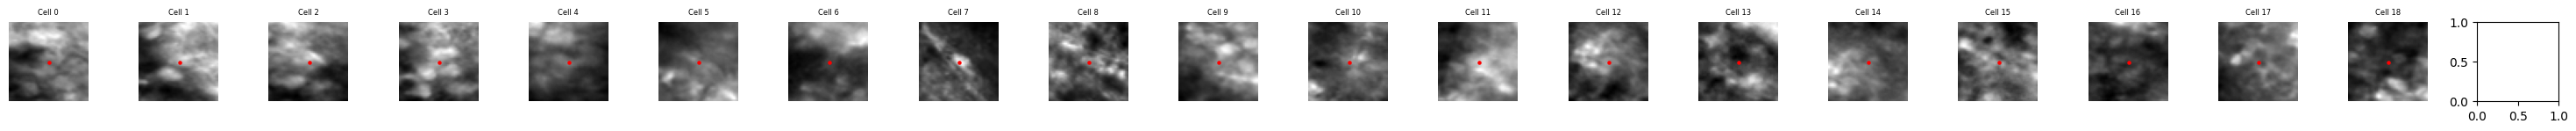

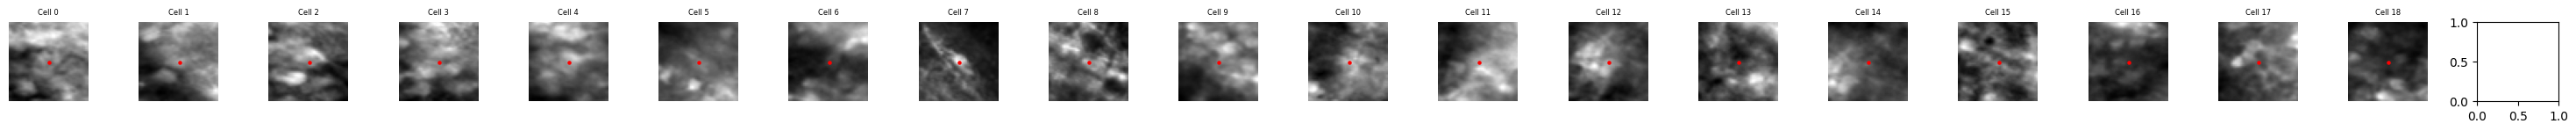

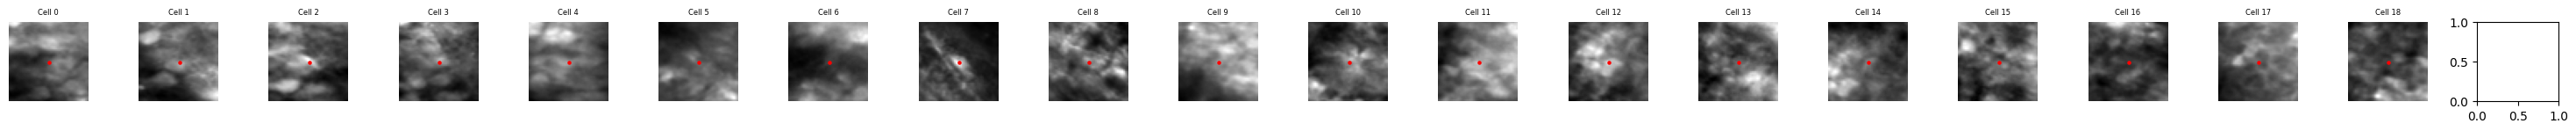

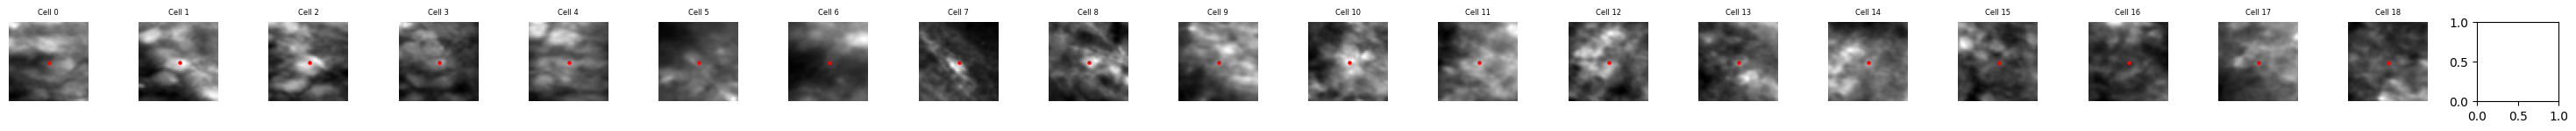

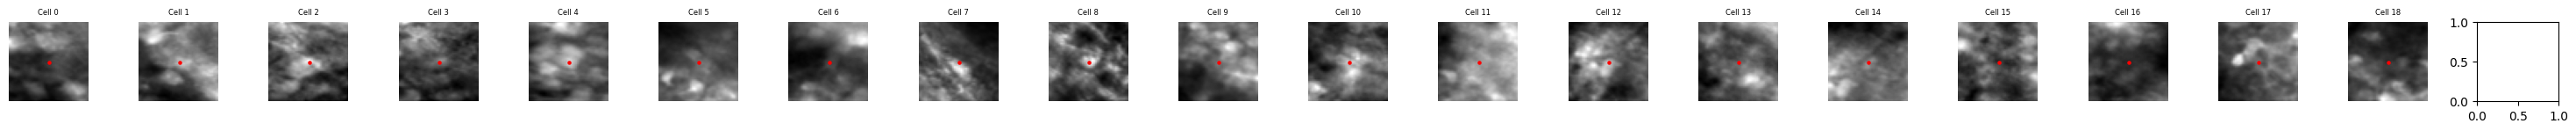

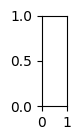

In [46]:
wind = 24

for i in range(len(track_ops.all_ds_path)):
    mean_img = all_ops[i]['meanImg']
    stat_t2p = all_stat_t2p[i]
    n_cells = len(stat_t2p)

    # Create one row of subplots, one column per neuron
    fig, axes = plt.subplots(1, n_cells+1, figsize=(1.5*n_cells+1, 1.5))

    if n_cells == 1:
        axes = [axes]  # ensure iterable

    for nrn_idx in range(n_cells):
        ax = axes[nrn_idx]

        # Check if current dataset has the median coord
        if stat_t2p[nrn_idx] is not None and 'med' in stat_t2p[nrn_idx]:
            median_coord = stat_t2p[nrn_idx]['med']
            cmap = 'gray'
        else:
            # fallback to previous dataset
            median_coord = all_stat_t2p[i-1][nrn_idx].get('med', None)
            cmap = 'pink'

        r, c = int(median_coord[0]), int(median_coord[1])
        img_window = mean_img[r - wind : r + wind,
                              c - wind : c + wind]

        ax.imshow(img_window, cmap=cmap)
        ax.scatter(wind, wind, s=5, c='red')
        ax.set_title(f'Cell {nrn_idx}', fontsize=6)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
